1. Construcción del DataFrame con datos lineales simples

          X         y
0  0.000000  1.000000
1  0.204082  1.408163
2  0.408163  1.816327
3  0.612245  2.224490
4  0.816327  2.632653


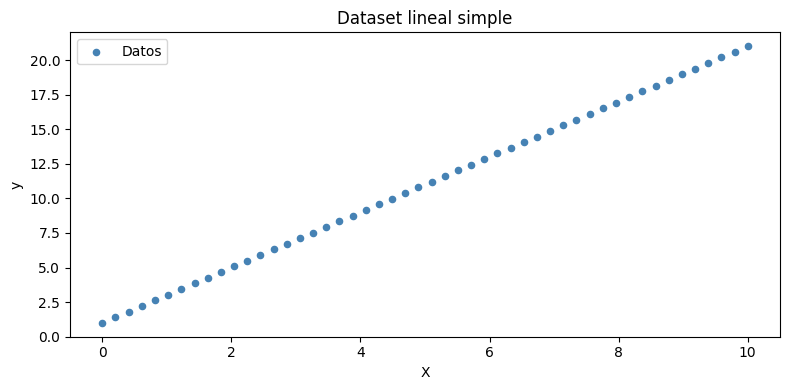

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# Datos lineales simples: y = 2x + 1
np.random.seed(42)
X = np.linspace(0, 10, 50)
y = 2 * X + 1
 
df = pd.DataFrame({'X': X, 'y': y})
print(df.head())
 
# Grafico de los datos
plt.figure(figsize=(8, 4))
plt.scatter(df['X'], df['y'], color='steelblue', s=20, label='Datos')
plt.xlabel('X')  ;  plt.ylabel('y')
plt.title('Dataset lineal simple')
plt.legend()  ;  plt.tight_layout()  ;  plt.show()


2. Definición de la función que calcule la función de coste cuadrática para un modelo de regresión lineal.

In [9]:
def hipotesis(X, theta0, theta1):
    """Modelo lineal: h(X) = theta0 + theta1 * X"""
    return theta0 + theta1 * X
 
def costo(X, y, theta0, theta1):
    """
    Funcion de coste cuadratica (MSE / 2).
    J = (1/2m) * sum( (h(x_i) - y_i)^2 )
    """
    m = len(y)
    h = hipotesis(X, theta0, theta1)
    return (1 / (2 * m)) * np.sum((h - y) ** 2)
 
# Prueba rapida
print('J(0, 2):', costo(X, y, 0, 2))   # debe ser ~0.25 (solo el intercepto falta)
print('J(1, 2):', costo(X, y, 1, 2))   # debe ser ~0


J(0, 2): 0.5
J(1, 2): 0.0


3. Fijar theta0=0, evaluar J para diferentes theta1 y graficar

Mejor theta1 = 2.1357


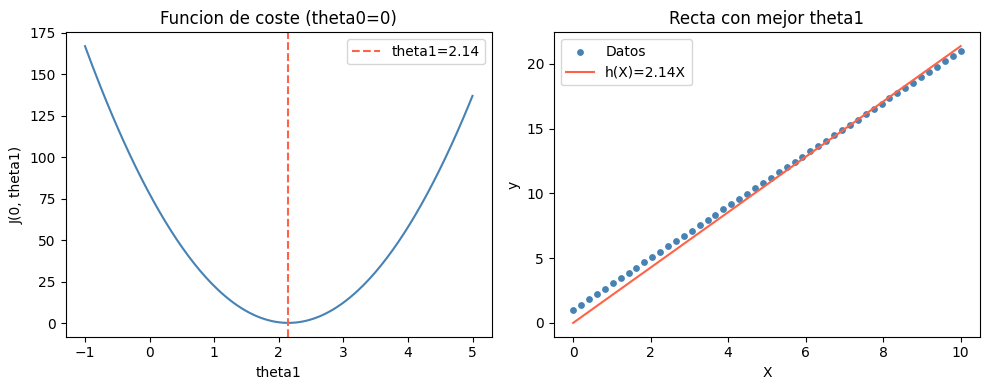

In [10]:
theta1_vals = np.linspace(-1, 5, 200)
costos = [costo(X, y, 0, t1) for t1 in theta1_vals]
 
mejor_t1 = theta1_vals[np.argmin(costos)]
print(f'Mejor theta1 = {mejor_t1:.4f}')
 
# Grafico J vs theta1
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(theta1_vals, costos, color='steelblue')
plt.axvline(mejor_t1, color='tomato', linestyle='--', label=f'theta1={mejor_t1:.2f}')
plt.xlabel('theta1')  ;  plt.ylabel('J(0, theta1)')
plt.title('Funcion de coste (theta0=0)')
plt.legend()
 
# Recta ajustada sobre los datos
plt.subplot(1, 2, 2)
plt.scatter(X, y, s=15, color='steelblue', label='Datos')
plt.plot(X, hipotesis(X, 0, mejor_t1), color='tomato', label=f'h(X)={mejor_t1:.2f}X')
plt.xlabel('X')  ;  plt.ylabel('y')
plt.title('Recta con mejor theta1')
plt.legend()
plt.tight_layout()  ;  plt.show()


4. Variar theta0 y theta1: malla con meshgrid, superficie y curvas de nivel

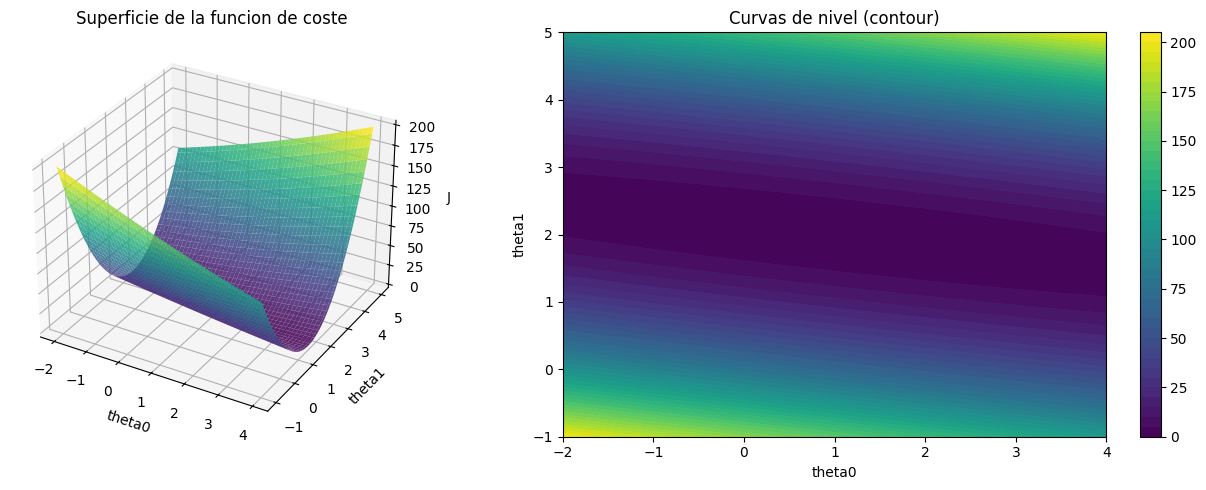

In [11]:
t0_range = np.linspace(-2, 4, 100)
t1_range = np.linspace(-1, 5, 100)
T0, T1 = np.meshgrid(t0_range, t1_range)
 
# Evaluar J en cada punto de la malla
J_malla = np.array([[costo(X, y, t0, t1)
                     for t0 in t0_range]
                    for t1 in t1_range])
 
fig = plt.figure(figsize=(14, 5))
 
# Superficie 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(T0, T1, J_malla, cmap='viridis', alpha=0.85)
ax1.set_xlabel('theta0')  ;  ax1.set_ylabel('theta1')  ;  ax1.set_zlabel('J')
ax1.set_title('Superficie de la funcion de coste')
 
# Curvas de nivel
ax2 = fig.add_subplot(1, 2, 2)
cp = ax2.contourf(T0, T1, J_malla, levels=40, cmap='viridis')
fig.colorbar(cp, ax=ax2)
ax2.set_xlabel('theta0')  ;  ax2.set_ylabel('theta1')
ax2.set_title('Curvas de nivel (contour)')
plt.tight_layout()  ;  plt.show()


5. Interpretar la forma de J e identificar el minimo global

Minimo en malla -> theta0=1.152, theta1=1.970
J minimo = 0.003982


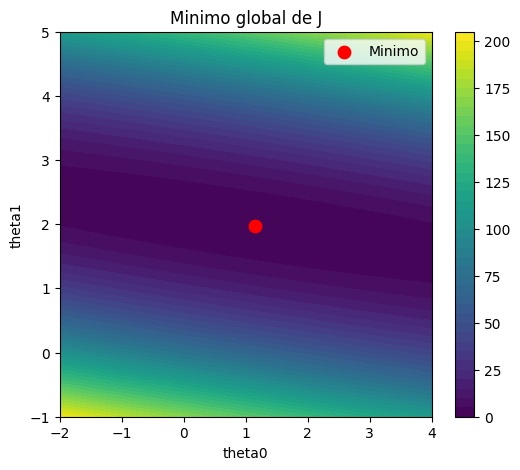

In [12]:
idx_min = np.unravel_index(np.argmin(J_malla), J_malla.shape)
t0_min = t0_range[idx_min[1]]
t1_min = t1_range[idx_min[0]]
print(f'Minimo en malla -> theta0={t0_min:.3f}, theta1={t1_min:.3f}')
print(f'J minimo = {J_malla[idx_min]:.6f}')
 
# Marcar minimo en el contour
plt.figure(figsize=(6, 5))
plt.contourf(T0, T1, J_malla, levels=40, cmap='viridis')
plt.colorbar()
plt.scatter(t0_min, t1_min, color='red', zorder=5, s=80, label='Minimo')
plt.xlabel('theta0')  ;  plt.ylabel('theta1')
plt.title('Minimo global de J')  ;  plt.legend()  ;  plt.show()


6. Repetir con datos con ruido y comparar con el caso ideal

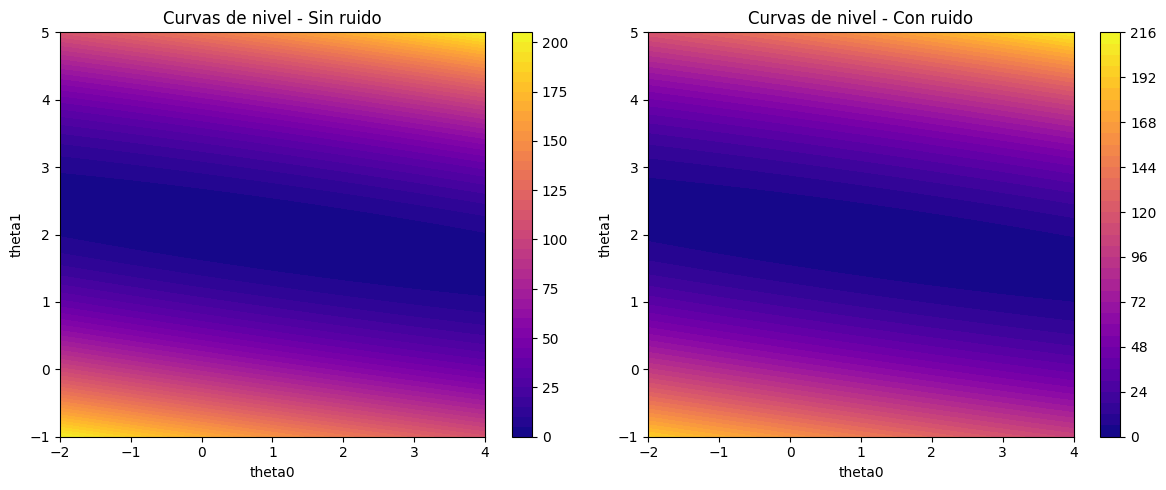

Ideal : theta0=1.152, theta1=1.970
Ruido : theta0=1.091, theta1=1.909


In [13]:
# Datos con ruido gaussiano
y_ruido = 2 * X + 1 + np.random.normal(0, 1.5, len(X))
df_ruido = pd.DataFrame({'X': X, 'y': y_ruido})
 
# Calcular J sobre la malla con datos ruidosos
J_ruido = np.array([[costo(X, y_ruido, t0, t1)
                     for t0 in t0_range]
                    for t1 in t1_range])
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, J_data, title in zip(axes,
                              [J_malla, J_ruido],
                              ['Sin ruido', 'Con ruido']):
    cp = ax.contourf(T0, T1, J_data, levels=40, cmap='plasma')
    fig.colorbar(cp, ax=ax)
    ax.set_xlabel('theta0')  ;  ax.set_ylabel('theta1')
    ax.set_title(f'Curvas de nivel - {title}')
plt.tight_layout()  ;  plt.show()
 
# Comparar los minimos
idx2 = np.unravel_index(np.argmin(J_ruido), J_ruido.shape)
print(f'Ideal : theta0={t0_min:.3f}, theta1={t1_min:.3f}')
print(f'Ruido : theta0={t0_range[idx2[1]]:.3f}, theta1={t1_range[idx2[0]]:.3f}')


7. Introducir un valor atipico (outlier) y analizar su efecto

Con outlier: theta0=1.879, theta1=1.909


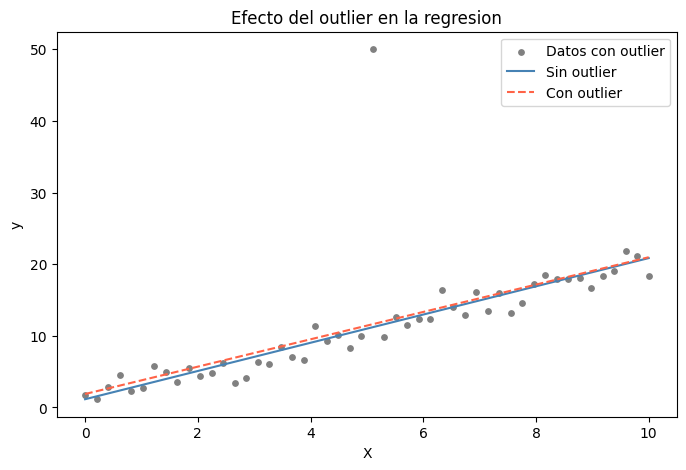

In [15]:
y_outlier = y_ruido.copy()
y_outlier[25] = 50   # valor atipico exagerado
 
J_outlier = np.array([[costo(X, y_outlier, t0, t1)
                       for t0 in t0_range]
                      for t1 in t1_range])
 
idx3 = np.unravel_index(np.argmin(J_outlier), J_outlier.shape)
print(f'Con outlier: theta0={t0_range[idx3[1]]:.3f}, theta1={t1_range[idx3[0]]:.3f}')
 
# Grafico comparativo de rectas
plt.figure(figsize=(8, 5))
plt.scatter(X, y_outlier, s=15, color='gray', label='Datos con outlier')
plt.plot(X, hipotesis(X, t0_min, t1_min),
         color='steelblue', label='Sin outlier')
plt.plot(X, hipotesis(X, t0_range[idx3[1]], t1_range[idx3[0]]),
         color='tomato', linestyle='--', label='Con outlier')
plt.xlabel('X')  ;  plt.ylabel('y')
plt.title('Efecto del outlier en la regresion')  ;  plt.legend()  ;  plt.show()


8. Ajustar modelo lineal sobre datos no lineales y discutir

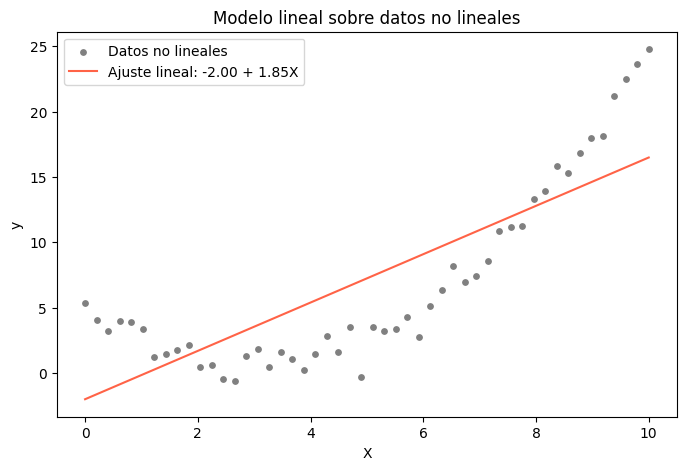

J minimo (no lineal): 7.891927385822803


In [16]:
# Datos no lineales: cuadratica + ruido
y_nolineal = 0.5 * X**2 - 3*X + 5 + np.random.normal(0, 1, len(X))
 
# Minimo de J para datos no lineales
J_nolin = np.array([[costo(X, y_nolineal, t0, t1)
                     for t0 in t0_range]
                    for t1 in t1_range])
idx4 = np.unravel_index(np.argmin(J_nolin), J_nolin.shape)
t0_nlin, t1_nlin = t0_range[idx4[1]], t1_range[idx4[0]]
 
plt.figure(figsize=(8, 5))
plt.scatter(X, y_nolineal, s=15, color='gray', label='Datos no lineales')
plt.plot(X, hipotesis(X, t0_nlin, t1_nlin), color='tomato',
         label=f'Ajuste lineal: {t0_nlin:.2f} + {t1_nlin:.2f}X')
plt.xlabel('X')  ;  plt.ylabel('y')
plt.title('Modelo lineal sobre datos no lineales')  ;  plt.legend()  ;  plt.show()
 
print('J minimo (no lineal):', J_nolin[idx4])


Discusion: minimizar J no garantiza buen modelo si la hipotesis es inadecuada. Un modelo lineal siempre encontrara su 'mejor recta', pero no capturara la curvatura real

9. Expresion teorica de la funcion de coste e interpretacion

Con un parametro (theta0=0, buscar theta1):

In [17]:
# J(theta1) = (1/2m) * sum((theta1*x_i - y_i)^2)
# Expandiendo: J = (theta1^2 * sum(x^2) - 2*theta1*sum(x*y) + sum(y^2)) / (2m)
# Minimo analitico: theta1* = sum(x*y) / sum(x^2)
 
theta1_analitico = np.sum(X * y) / np.sum(X**2)
print(f'theta1 analitico (theta0=0): {theta1_analitico:.6f}')


theta1 analitico (theta0=0): 2.148485


Con dos parametros (theta0 y theta1 libres):

In [18]:
# Ecuaciones normales: Theta* = (X^T X)^{-1} X^T y
X_mat = np.column_stack([np.ones(len(X)), X])  # matriz de diseno (m x 2)
theta_analitico = np.linalg.pinv(X_mat.T @ X_mat) @ X_mat.T @ y
print(f'theta0 analitico: {theta_analitico[0]:.6f}')
print(f'theta1 analitico: {theta_analitico[1]:.6f}')
# Deben ser ~1.0 y ~2.0 para nuestros datos


theta0 analitico: 1.000000
theta1 analitico: 2.000000


GRADIENTE DESCENDENTE

10. Algoritmo de gradiente descendente

alpha=0.01:
  Convergio en 352 iteraciones -> x* = 4.004895
alpha=0.1:
  Convergio en 44 iteraciones -> x* = 4.000327
alpha=0.9:
  Convergio en 53 iteraciones -> x* = 3.999956


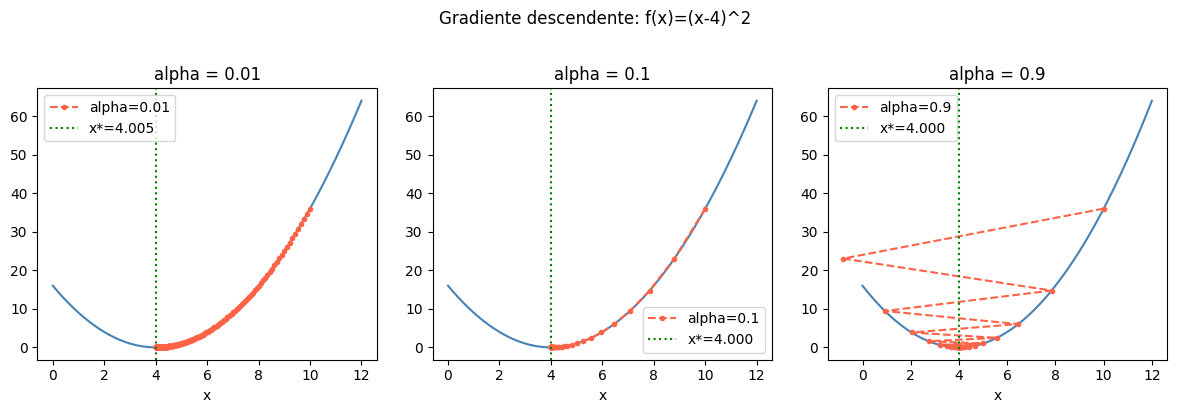

In [19]:
def grad_desc_1d(f_deriv, x0, alpha, epsilon=1e-4, max_iter=10000):
    """
    Gradiente descendente en 1D.
    f_deriv : funcion derivada de f
    x0      : punto inicial
    alpha   : tasa de aprendizaje
    epsilon : criterio de parada (|delta_x| < epsilon)
    """
    x = x0
    historia = [x]
    for i in range(max_iter):
        delta = -alpha * f_deriv(x)
        x = x + delta
        historia.append(x)
        if abs(delta) < epsilon:
            print(f'  Convergio en {i+1} iteraciones -> x* = {x:.6f}')
            break
    return x, np.array(historia)
 
# f(x) = (x-4)^2  =>  f'(x) = 2*(x-4)
f       = lambda x: (x - 4)**2
f_prima = lambda x: 2 * (x - 4)
 
alphas = [0.01, 0.1, 0.9]
x0 = 10.0
 
plt.figure(figsize=(12, 4))
x_plot = np.linspace(0, 12, 300)
 
for i, alpha in enumerate(alphas):
    print(f'alpha={alpha}:')
    x_opt, hist = grad_desc_1d(f_prima, x0, alpha)
    ax = plt.subplot(1, 3, i+1)
    ax.plot(x_plot, f(x_plot), 'steelblue')
    ax.plot(hist, f(hist), 'o--', color='tomato', ms=3, label=f'alpha={alpha}')
    ax.axvline(x_opt, color='green', linestyle=':', label=f'x*={x_opt:.3f}')
    ax.set_title(f'alpha = {alpha}')  ;  ax.legend()  ;  ax.set_xlabel('x')
 
plt.suptitle('Gradiente descendente: f(x)=(x-4)^2', y=1.02)
plt.tight_layout()  ;  plt.show()


11. Minimo de F(x,y) = sin(0.5x^2 - 0.25y^2 + 3) * cos(2x+1-e^y)

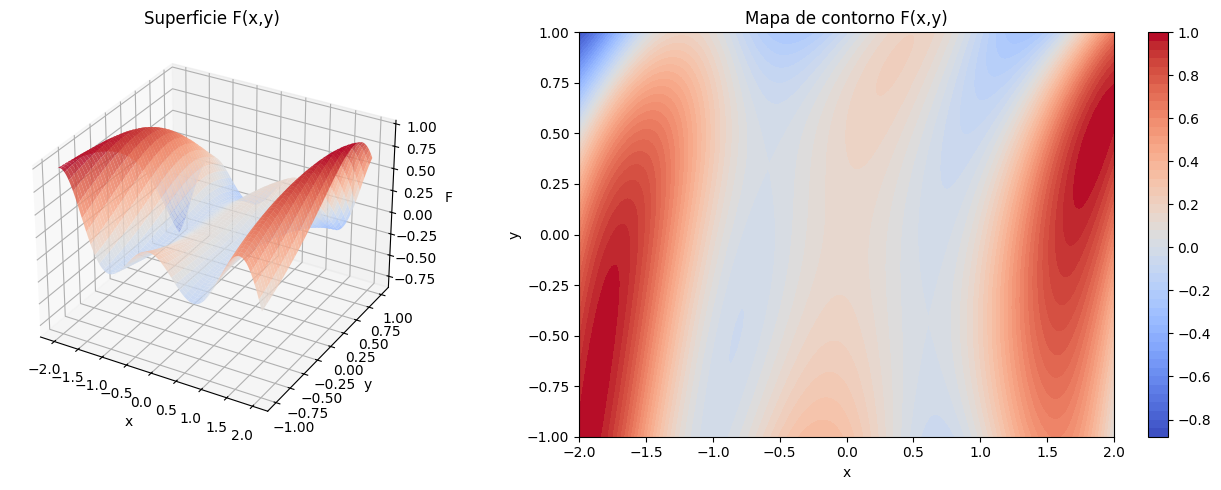

Inicio (0.5, 0.5):
  Convergio en 1292 iter -> x*=2.19569, y*=1.68420, F=-0.99993
Inicio (-1.0, 0.0):
  Convergio en 1550 iter -> x*=-0.78632, y*=-0.39611, F=-0.04089
Inicio (1.5, -0.5):
  Convergio en 1736 iter -> x*=1.09481, y*=-2.83965, F=-0.99987


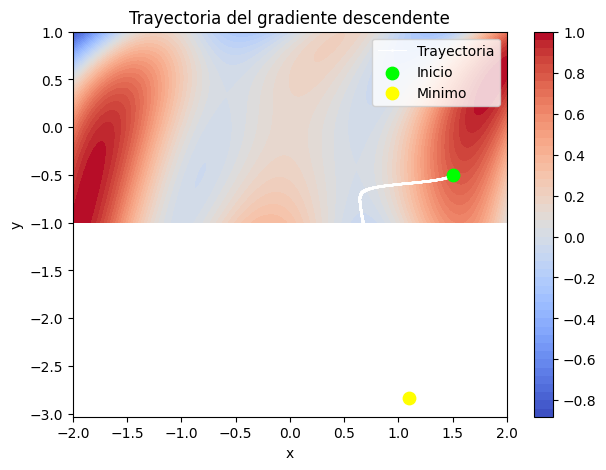

In [21]:
# ── Definicion de la funcion ──
def F(x, y):
    return np.sin(0.5*x**2 - 0.25*y**2 + 3) * np.cos(2*x + 1 - np.exp(y))
 
# ── Grafica 3D y contorno ──
x_r = np.linspace(-2, 2, 200)
y_r = np.linspace(-1, 1, 200)
Xg, Yg = np.meshgrid(x_r, y_r)
Zg = F(Xg, Yg)
 
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(Xg, Yg, Zg, cmap='coolwarm', alpha=0.85)
ax1.set_xlabel('x')  ;  ax1.set_ylabel('y')  ;  ax1.set_zlabel('F')
ax1.set_title('Superficie F(x,y)')
 
ax2 = fig.add_subplot(1, 2, 2)
cp = ax2.contourf(Xg, Yg, Zg, levels=50, cmap='coolwarm')
fig.colorbar(cp, ax=ax2)
ax2.set_xlabel('x')  ;  ax2.set_ylabel('y')
ax2.set_title('Mapa de contorno F(x,y)')
plt.tight_layout()  ;  plt.show()
 
# ── Gradiente descendente 2D con gradiente numerico ──
def grad_numerico(func, x, y, h=1e-5):
    """Gradiente por diferencias finitas centradas"""
    dfdx = (func(x+h, y) - func(x-h, y)) / (2*h)
    dfdy = (func(x, y+h) - func(x, y-h)) / (2*h)
    return dfdx, dfdy
 
def grad_desc_2d(func, x0, y0, alpha=0.01, epsilon=1e-4, max_iter=50000):
    x, y = x0, y0
    hist_x, hist_y = [x], [y]
    for i in range(max_iter):
        gx, gy = grad_numerico(func, x, y)
        x_new = x - alpha * gx
        y_new = y - alpha * gy
        hist_x.append(x_new)  ;  hist_y.append(y_new)
        if np.sqrt((x_new-x)**2 + (y_new-y)**2) < epsilon:
            print(f'  Convergio en {i+1} iter -> x*={x_new:.5f}, y*={y_new:.5f}, F={func(x_new,y_new):.5f}')
            break
        x, y = x_new, y_new
    return x, y, np.array(hist_x), np.array(hist_y)
 
# Probar con diferentes puntos iniciales
for x0, y0 in [(0.5, 0.5), (-1.0, 0.0), (1.5, -0.5)]:
    print(f'Inicio ({x0}, {y0}):')
    xopt, yopt, hx, hy = grad_desc_2d(F, x0, y0, alpha=0.005)
 
# Trazar trayectoria del ultimo punto inicial
plt.figure(figsize=(7, 5))
plt.contourf(Xg, Yg, Zg, levels=50, cmap='coolwarm')
plt.colorbar()
plt.plot(hx, hy, 'w.-', ms=2, linewidth=0.8, label='Trayectoria')
plt.scatter(hx[0], hy[0], color='lime', zorder=5, s=80, label='Inicio')
plt.scatter(hx[-1], hy[-1], color='yellow', zorder=5, s=80, label='Minimo')
plt.xlabel('x')  ;  plt.ylabel('y')
plt.title('Trayectoria del gradiente descendente')  ;  plt.legend()  ;  plt.show()


## Modelo de *machine learning*: solución general


Paso 12.a  Regresion lineal con gradiente descendente (datos del lab)

  Convergio en 36 iteraciones
theta0 = 0.221554  (esperado ~0.2)
theta1 = 0.177090  (esperado ~0.2)


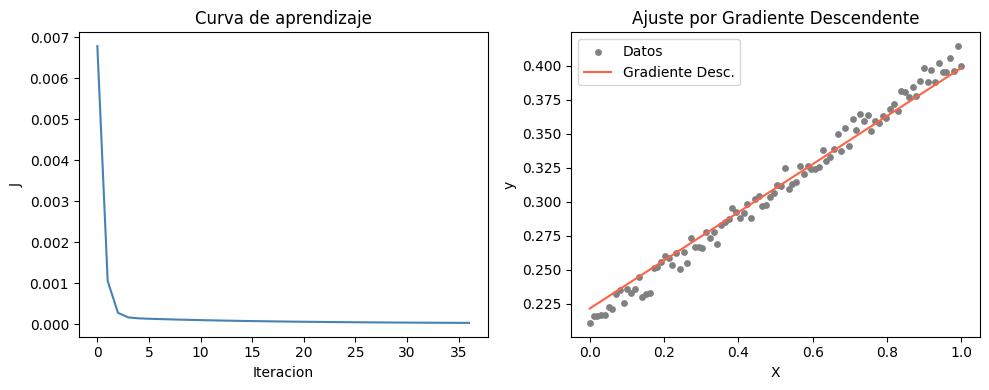

In [22]:
# Datos del laboratorio
np.random.seed(0)
X_lab = np.linspace(0, 1, 100)
y_lab = 0.2 + 0.2*X_lab + 0.02*np.random.random(100)
 
# Gradiente de J respecto a theta0 y theta1
def gradientes(X, y, theta0, theta1):
    m = len(y)
    h = hipotesis(X, theta0, theta1)
    error = h - y
    grad0 = (1/m) * np.sum(error)
    grad1 = (1/m) * np.sum(error * X)
    return grad0, grad1
 
def entrenar_regresion(X, y, alpha=0.1, epsilon=1e-6, max_iter=100000):
    """Entrena regresion lineal por gradiente descendente"""
    theta0, theta1 = 0.0, 0.0
    historial_J = []
    for i in range(max_iter):
        g0, g1 = gradientes(X, y, theta0, theta1)
        theta0 -= alpha * g0
        theta1 -= alpha * g1
        J = costo(X, y, theta0, theta1)
        historial_J.append(J)
        if i > 0 and abs(historial_J[-2] - J) < epsilon:
            print(f'  Convergio en {i} iteraciones')
            break
    return theta0, theta1, historial_J
 
t0_gd, t1_gd, hist_J = entrenar_regresion(X_lab, y_lab, alpha=0.5)
print(f'theta0 = {t0_gd:.6f}  (esperado ~0.2)')
print(f'theta1 = {t1_gd:.6f}  (esperado ~0.2)')
 
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_J, color='steelblue')
plt.xlabel('Iteracion')  ;  plt.ylabel('J')
plt.title('Curva de aprendizaje')
 
plt.subplot(1, 2, 2)
plt.scatter(X_lab, y_lab, s=15, color='gray', label='Datos')
plt.plot(X_lab, hipotesis(X_lab, t0_gd, t1_gd), color='tomato', label='Gradiente Desc.')
plt.xlabel('X')  ;  plt.ylabel('y')
plt.title('Ajuste por Gradiente Descendente')  ;  plt.legend()
plt.tight_layout()  ;  plt.show()


Paso 12.b  Comparar con LinearRegression de scikit-learn

--- Comparacion de parametros ---
Gradiente Desc.: theta0=0.221554, theta1=0.177090
scikit-learn   : theta0=0.211957, theta1=0.194998


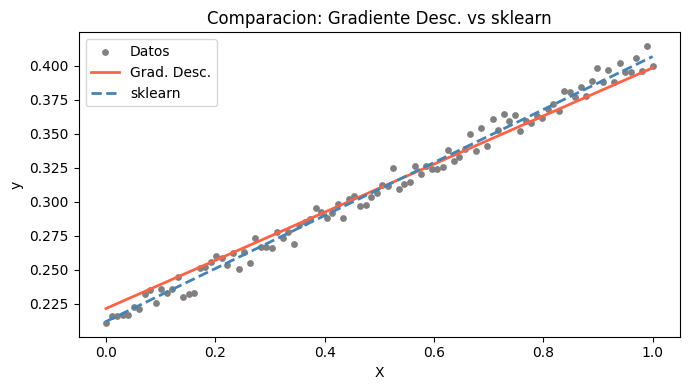

In [23]:
from sklearn.linear_model import LinearRegression
 
modelo_sk = LinearRegression()
modelo_sk.fit(X_lab.reshape(-1, 1), y_lab)
 
print('--- Comparacion de parametros ---')
print(f'Gradiente Desc.: theta0={t0_gd:.6f}, theta1={t1_gd:.6f}')
print(f'scikit-learn   : theta0={modelo_sk.intercept_:.6f}, theta1={modelo_sk.coef_[0]:.6f}')
 
# Grafico comparativo
y_pred_sk = modelo_sk.predict(X_lab.reshape(-1, 1))
plt.figure(figsize=(7, 4))
plt.scatter(X_lab, y_lab, s=15, color='gray', label='Datos')
plt.plot(X_lab, hipotesis(X_lab, t0_gd, t1_gd), 'tomato', lw=2, label='Grad. Desc.')
plt.plot(X_lab, y_pred_sk, 'steelblue', lw=2, linestyle='--', label='sklearn')
plt.xlabel('X')  ;  plt.ylabel('y')
plt.title('Comparacion: Gradiente Desc. vs sklearn')  ;  plt.legend()
plt.tight_layout()  ;  plt.show()
